In [ ]:
# Before we start, let's create a new virtual invironment.
    # Windows/macOS/Linux: python -m venv .venv

# Activate:
    # Windows: .venv\Scripts\activate
    # macOS/Linux: source .venv/bin/activate

# Ensure pip: python -m ensurepip --default-pip

# Install packages:
    # pip install -r requirements.txt

In [1]:
# Let's load our packages
from pathlib import Path
import cv2
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import PIL
import numpy as np
import os
import datetime
from torch.nn import functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
import pandas as pd

from dataset import RetinaDataset
import metrics
from losses import Dice_and_FocalLoss

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# DEVICE='cpu'

```
# We will be working with the DRIVE (Digital Retinal Images for Vessel Extraction)
# dataset. (https://drive.grand-challenge.org/). We have included the data in a folder for you to download.
# You don't have to code anything yourself, the code can be run from start to finish.
# However, you should recognize and understand what is happening at each stage.

The DRIVE database has been established to enable comparative studies on segmentation of blood vessels in retinal images. Retinal vessel segmentation and delineation of morphological attributes of retinal blood vessels, such as length, width, tortuosity, branching patterns and angles are utilized for the diagnosis, screening, treatment, and evaluation of various cardiovascular and ophthalmologic diseases such as diabetes, hypertension, arteriosclerosis and chorodial neovascularization. Automatic detection and analysis of the vasculature can assist in the implementation of screening programs for diabetic retinopathy, can aid research on the relationship between vessel tortuosity and hypertensive retinopathy, vessel diameter measurement in relation with diagnosis of hypertension, and computer-assisted laser surgery. Automatic generation of retinal maps and extraction of branch points have been used for temporal or multimodal image registration and retinal image mosaic synthesis. Moreover, the retinal vascular tree is found to be unique for each individual and can be used for biometric identification.

The photographs for the DRIVE database were obtained from a diabetic retinopathy screening program in The Netherlands. The screening population consisted of 400 diabetic subjects between 25-90 years of age. Forty photographs have been randomly selected, 33 do not show any sign of diabetic retinopathy and 7 show signs of mild early diabetic retinopathy
```

In [ ]:
# Question: Before we start training our segmentation model. What can you already say
# about this dataset with respect to deep learning.


In [ ]:
# Let's load and visualize our data. We loop through our dataset and store its
# content in a list
data_path = Path(Path.cwd() / "dataset/train")
data_path_validate = Path(Path.cwd() / "dataset/validate")

def load_dataset(data_path, resize_dims, convert_to_grayscale):
    imgs = sorted(os.listdir(Path(data_path / "image")))
    masks = sorted(os.listdir(Path(data_path / "mask")))
    fov_masks = sorted(os.listdir(Path(data_path / "fov_mask")))

    images = []
    ground_truths = []

    for i in range(0, len(imgs)):
        # Check if indices match:
        img_name = imgs[i]
        mask_name = masks[i]
        fov_mask_name = fov_masks[i]

        if img_name[0:3] == mask_name[0:3]:
            img_path = Path(data_path / "image" / img_name)
            mask_path = Path(data_path / "fov_mask" / fov_mask_name)
            gt_path = Path(data_path / "mask" / mask_name)

            if convert_to_grayscale:
                img = PIL.Image.open(img_path).convert("L")
                mask = PIL.Image.open(mask_path).convert("L")


                img = img.resize(resize_dims, PIL.Image.NEAREST)
                mask = mask.resize(resize_dims, PIL.Image.NEAREST)
                images.append(np.array(img)*np.array(mask))

                gt = PIL.Image.open(gt_path)
                gt = np.array(gt.resize(resize_dims, PIL.Image.NEAREST))
                gt[gt != 0] = 1
                ground_truths.append(gt)
            else:
                images.append(PIL.Image.open(img_path))
                ground_truths.append(np.array(PIL.Image.open(gt_path)))
        else:
            print("Index mismatch!")
    return images, ground_truths


images, ground_truths = load_dataset(data_path=data_path, resize_dims=(512, 512), convert_to_grayscale=False)

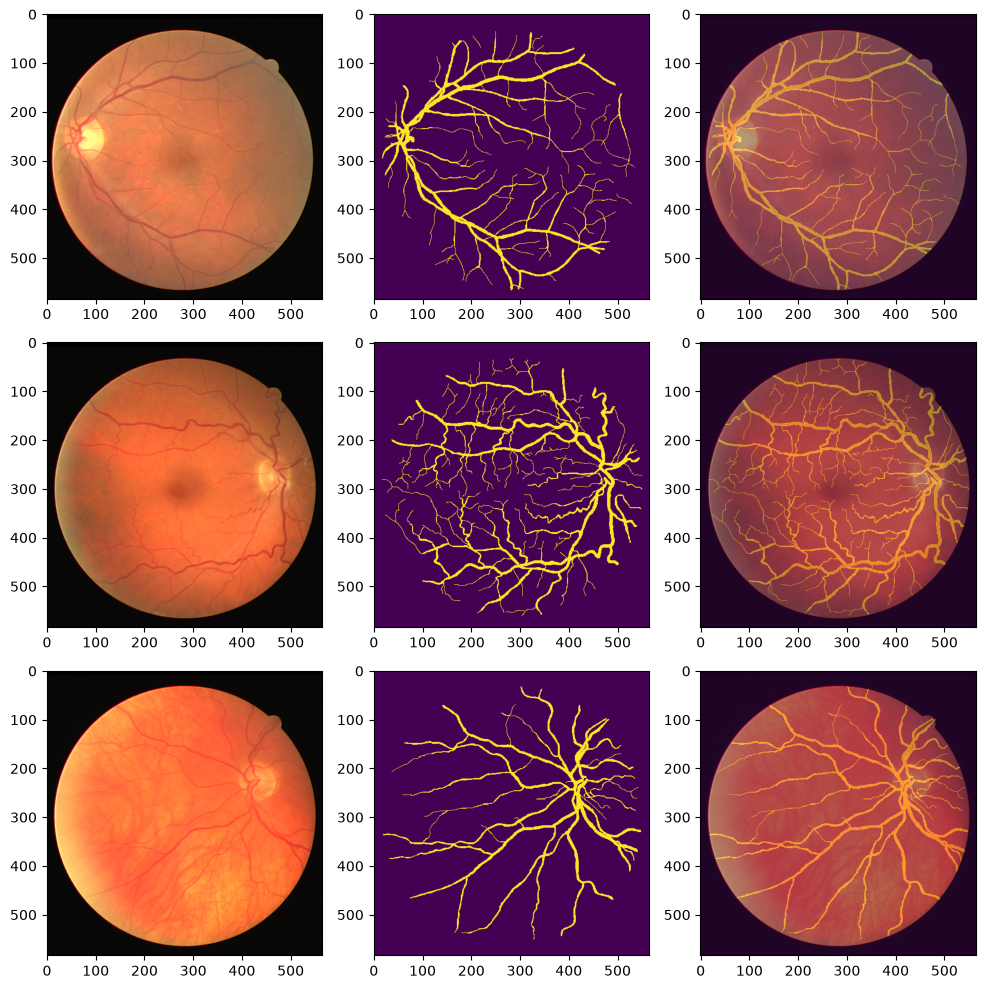

In [3]:
# Let's visualize
fig, ax = plt.subplots(3,3, figsize=(10, 10))
ax[0, 0].imshow(images[0])
ax[0, 1].imshow(ground_truths[0])
ax[0, 2].imshow(images[0])
ax[0, 2].imshow(ground_truths[0], alpha=0.4)

ax[1, 0].imshow(images[1])
ax[1, 1].imshow(ground_truths[1])
ax[1, 2].imshow(images[1])
ax[1, 2].imshow(ground_truths[1], alpha=0.4)

ax[2, 0].imshow(images[2])
ax[2, 1].imshow(ground_truths[2])
ax[2, 2].imshow(images[2])
ax[2, 2].imshow(ground_truths[2], alpha=0.4)

plt.tight_layout()

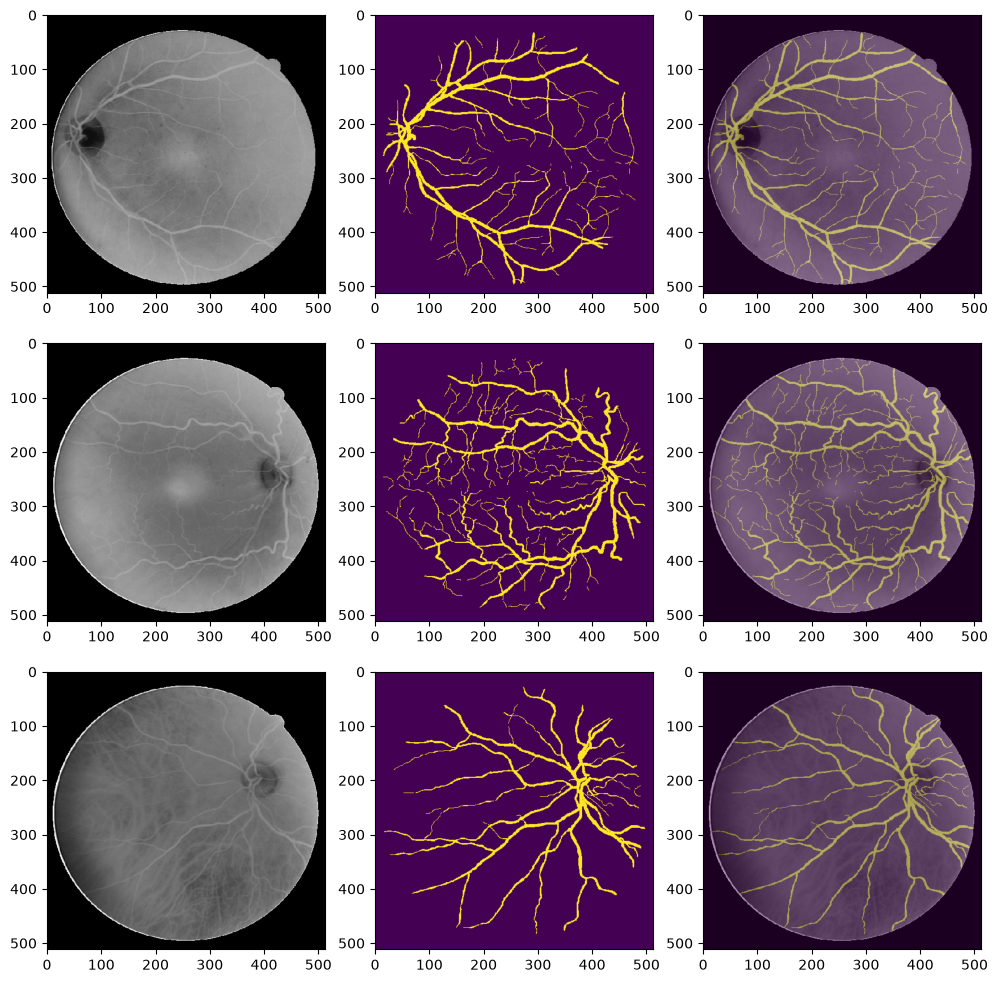

In [ ]:
# The previous images are in colour. They are RGB images.
# Let's load our data again, but this time we convert to grayscale and resize our image
# dimensions.
images, ground_truths = load_dataset(data_path=data_path, resize_dims=(512, 512), convert_to_grayscale=True)
images_validate, ground_truths_validate = load_dataset(data_path=data_path_validate, resize_dims=(512, 512), convert_to_grayscale=True)

# Let's visualize
fig, ax = plt.subplots(3,3, figsize=(10, 10))
ax[0, 0].imshow(images[0], cmap= 'gray')
ax[0, 1].imshow(ground_truths[0])
ax[0, 2].imshow(images[0], cmap='gray')
ax[0, 2].imshow(ground_truths[0], alpha=0.4)

ax[1, 0].imshow(images[1], cmap='gray')
ax[1, 1].imshow(ground_truths[1])
ax[1, 2].imshow(images[1], cmap='gray')
ax[1, 2].imshow(ground_truths[1], alpha=0.4)

ax[2, 0].imshow(images[2], cmap='gray')
ax[2, 1].imshow(ground_truths[2])
ax[2, 2].imshow(images[2], cmap='gray')
ax[2, 2].imshow(ground_truths[2], alpha=0.4)

plt.tight_layout()
a = ground_truths[0]
aa = np.where(a == 1)

In [ ]:
# We have now converted our image size from (512, 512, 3) to (512, 512, 1)
# Question: Why do we convert from RGB to Grayscale in this case

In [ ]:
# This is our standard UNet architecture.
def double_conv(in_c, out_c, dropout_rate):
    conv = nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=3, padding="same"),
        nn.PReLU(),
        nn.BatchNorm2d(out_c),
        nn.Dropout(dropout_rate),
        nn.Conv2d(out_c, out_c, kernel_size=3, padding="same"),
        nn.PReLU(),
        nn.BatchNorm2d(out_c),
    )
    return conv

class UNet(nn.Module):
    def __init__(self, num_classes, dropout_rate):
        super(UNet, self).__init__()
        # num_classes = params.dict['num_classes_bc']

        self.max_pool_2x2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.down_conv_1 = double_conv(1, 32, dropout_rate)
        self.down_conv_2 = double_conv(32, 64, dropout_rate)
        self.down_conv_3 = double_conv(64, 128, dropout_rate)
        self.down_conv_4 = double_conv(128, 256, dropout_rate)
        self.down_conv_5 = double_conv(256, 512, dropout_rate)

        self.up_trans_1 = nn.ConvTranspose2d(
            in_channels=512, out_channels=256, kernel_size=2, stride=2
        )

        self.up_conv_1 = double_conv(512, 256, dropout_rate)

        self.up_trans_2 = nn.ConvTranspose2d(
            in_channels=256, out_channels=128, kernel_size=2, stride=2
        )

        self.up_conv_2 = double_conv(256, 128, dropout_rate)

        self.up_trans_3 = nn.ConvTranspose2d(
            in_channels=128, out_channels=64, kernel_size=2, stride=2
        )

        self.up_conv_3 = double_conv(128, 64, dropout_rate)

        self.up_trans_4 = nn.ConvTranspose2d(
            in_channels=64, out_channels=32, kernel_size=2, stride=2
        )

        self.up_conv_4 = double_conv(64, 32, dropout_rate)

        self.out = nn.Conv2d(in_channels=32, out_channels=num_classes, kernel_size=1)

    def forward(self, image):

        x1 = self.down_conv_1(image)
        # after each convolution apply max_pooling
        p1 = self.max_pool_2x2(x1)

        x2 = self.down_conv_2(p1)
        p2 = self.max_pool_2x2(x2)

        x3 = self.down_conv_3(p2)
        p3 = self.max_pool_2x2(x3)

        x4 = self.down_conv_4(p3)
        p4 = self.max_pool_2x2(x4)

        x5 = self.down_conv_5(p4)

        # decoder
        u6 = self.up_trans_1(x5)
        x6 = self.up_conv_1(torch.cat([u6, x4], 1))

        u7 = self.up_trans_2(x6)
        x7 = self.up_conv_2(torch.cat([u7, x3], 1))

        u8 = self.up_trans_3(x7)
        x8 = self.up_conv_3(torch.cat([u8, x2], 1))

        u9 = self.up_trans_4(x8)
        x9 = self.up_conv_4(torch.cat([u9, x1], 1))

        x = self.out(x9)
        # x = F.softmax(x, dim=1)
        x = F.sigmoid(x)
        return x


In [ ]:
# Define our training and validation functions. The pytorch training loop refers to
# these functions constantly during training.

def train(model, optimizer, loss_fn, train_dl, metric,
          threshold, scheduler=False, device=DEVICE):

    model.train()

    epoch_loss = 0
    epoch_metric = 0
    batch_nr = 0

    for batch in train_dl:
        # Set optimizer to zero for safety
        optimizer.zero_grad()

        # Send data to device
        input = batch["input"].to(device, dtype=torch.float)
        target = batch["target"].to(device, dtype=torch.float)

        target = target.unsqueeze(1)

        # Forward pass
        prediction = model(input)

        # Prediction still has gradient information here
        loss = loss_fn(prediction, target)

        # Detach a COPY for calculating the metric
        prediction_binary = (prediction.detach() > threshold).float()

        metric_score = metric(prediction_binary, target, threshold)
        metric_score = torch.mean(metric_score)

        epoch_loss += loss.item()
        epoch_metric += metric_score.item()

        # Backpropagation using the ORIGINAL prediction
        loss.backward()
        optimizer.step()

        if scheduler:
            scheduler.step()

        batch_nr += 1

    epoch_loss /= batch_nr
    epoch_metric /= batch_nr

    return epoch_loss, epoch_metric


def validate(model, loss_fn, val_dl, metric, threshold, device=DEVICE):
    model.eval()
    epoch_loss = 0
    epoch_metric = 0
    batch_nr = 0

    with torch.no_grad():
        for batch in val_dl:
            input = batch["input"].to(device, dtype=torch.float)
            target = batch["target"].to(device, dtype=torch.float)
            target = target.unsqueeze(1)

            prediction = model(input)

            loss = loss_fn(prediction, target)

            # Detach a COPY for calculating the metric
            prediction_binary = (prediction.detach() > threshold).float()

            metric_score = metric(prediction_binary, target, threshold)
            metric_score = torch.mean(metric_score)

            epoch_loss += loss.item()
            epoch_metric += metric_score.item()

            del input, target, prediction, metric_score
            del loss

            batch_nr += 1

        epoch_loss /= batch_nr
        epoch_metric /= batch_nr

    return epoch_loss, epoch_metric

In [ ]:
# The UNet architecture contains operations for convolutions and max pooling.
# We previously resized our image to 512 x 512. The convolution and max pooling layer
# reduce the size of their input by 'kernel_size' and 'stride'. Would we have run into
#  problems had we not resized these images?
# Explain your reasoning

In [ ]:
# We define our data augmentations. Why are these helpful when training the model?
train_transforms = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Affine(rotate=(30, 30), translate_percent=(0.1, 0.1), interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST, p=0.5),
        ToTensorV2(),
    ]
)

validation_transforms = A.Compose(
    [
        ToTensorV2(),
    ]
)


In [ ]:
from dataset import RetinaDataset

train_dataset = RetinaDataset(imgs=np.asarray(images), gts=np.asarray(ground_truths), transform=train_transforms)
val_dataset = RetinaDataset(imgs=np.asarray(images_validate), gts=np.asarray(ground_truths_validate), transform=validation_transforms)

train_dataloader = DataLoader(
    train_dataset, batch_size=4, shuffle=True
)
validation_dataloader = DataLoader(
    val_dataset, batch_size=1, shuffle=False
)

# Question: In the Dataset function we normalize our images between 5th and 95th percentiles
# instead of straightforward min-max normalization. What effect has this on our performance?

In [ ]:
# Create directories for logs and models
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_path = Path.cwd() / "Experiments"
experiment_path = log_path / str(current_time)
save_model_path = experiment_path / "saved_models"
print(f"Saving to: {save_model_path}")
save_model_path.mkdir(parents=True, exist_ok=False)

In [12]:
# Initialize our model
model = UNet(num_classes=1, dropout_rate=0.5).to(device=DEVICE)
model.train()

UNet(
  (max_pool_2x2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down_conv_1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): PReLU(num_parameters=1)
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): PReLU(num_parameters=1)
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (down_conv_2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): PReLU(num_parameters=1)
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): PReLU(num_parameters=1)
    (6): BatchNorm2d(64, eps=1e-05, mo

In [ ]:
# Here we set which optimizer and loss function we want to use.

# AdamW
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    betas=(0.9, 0.99),
    weight_decay=0.0001,
)


# Learning Rate Schedule
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, eta_min=1e-5
)

# Define Loss
loss_function = Dice_and_FocalLoss()

# Define metric
metric = metrics.dice

In [ ]:
# This is our training loop. We have set the default number of training epochs to
# 1000 epochs. This may take a long time as we are training on CPU instead of GPU.
# We have provided a model that was trained for 1000 epochs if it takes too long.
# Remember to change the path locations later on if you want to use your own model.

print('Using device:', DEVICE)
print()

#Additional Info when using cuda
if DEVICE == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

# Set the number of epochs to train
num_epochs = 1000

# Create empty lists for logging purposes
epoch_list = []
epoch_list_val = []
train_loss_list = []
validation_loss_list = []
train_dice_list = []
validation_dice_list = []

# Set threshold for binarization of predictions
threshold = 0.5

# Training Loop
for epoch in range(num_epochs + 1):

    train_loss, train_dice = train(
        model=model,
        optimizer=optimizer,
        loss_fn=loss_function,
        train_dl=train_dataloader,
        metric=metric,
        threshold=threshold,
        scheduler=scheduler,
        device=DEVICE,
    )
    epoch_list.append(epoch)
    train_loss_list.append(train_loss)
    train_dice_list.append(train_dice)
    if epoch % 1 == 0:
        print(f"Epoch {epoch}, Loss: {train_loss:.5f}, Dice: {train_dice:.5f}")

    if epoch % 1 == 0:
        validation_loss, validation_dice = validate(
            model=model,
            loss_fn=loss_function,
            val_dl=validation_dataloader,
            metric=metric,
            threshold=threshold,
            device=DEVICE,
        )
        print(f"Validation Epoch {epoch}, Loss: {validation_loss:.5f}, Dice: {validation_dice:.5f}")
        epoch_list_val.append(epoch)
        validation_loss_list.append(validation_loss)
        validation_dice_list.append(validation_dice)

    # save model
    if epoch % 50 == 0:
        model_name = "model_weights" + str(epoch) + ".pt"
        torch.save(model.state_dict(), os.path.join(save_model_path, model_name))
        full_model_name = "model_state" + str(epoch) + ".pt"
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": train_loss,
                "scheduler": scheduler,
            },
            os.path.join(save_model_path, full_model_name),
        )
df = pd.DataFrame(
    {
        "epoch": epoch_list,
        "train_loss": train_loss_list,
        "train_dice": train_dice_list,
    }
)
df.to_csv(experiment_path / "train.csv", index=False)
df2 = pd.DataFrame(
    {
        "epoch": epoch_list_val,
        "val_loss": validation_loss_list,
        "val_dice": validation_dice_list,

    }
)
df2.to_csv(experiment_path / "validation.csv", index=False)

Using device: cuda

NVIDIA GeForce RTX 4080 SUPER
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB
Epoch 0, Loss: 1.08865, Dice: 0.17552
Validation Epoch 0, Loss: 1.07541, Dice: 0.15018
Epoch 1, Loss: 1.05832, Dice: 0.18353
Validation Epoch 1, Loss: 1.06971, Dice: 0.15044
Epoch 2, Loss: 1.03003, Dice: 0.21223
Validation Epoch 2, Loss: 0.97359, Dice: 0.38414
Epoch 3, Loss: 0.98844, Dice: 0.26784
Validation Epoch 3, Loss: 0.95567, Dice: 0.40820
Epoch 4, Loss: 0.97367, Dice: 0.31253
Validation Epoch 4, Loss: 0.87728, Dice: 0.47765
Epoch 5, Loss: 0.95318, Dice: 0.41182
Validation Epoch 5, Loss: 0.88497, Dice: 0.51508
Epoch 6, Loss: 0.94532, Dice: 0.40789
Validation Epoch 6, Loss: 0.86275, Dice: 0.57126
Epoch 7, Loss: 0.93226, Dice: 0.45649
Validation Epoch 7, Loss: 0.89948, Dice: 0.52261
Epoch 8, Loss: 0.92235, Dice: 0.47036
Validation Epoch 8, Loss: 0.91035, Dice: 0.43194
Epoch 9, Loss: 0.90533, Dice: 0.50985
Validation Epoch 9, Loss: 0.88355, Dice: 0.56825
Epoch 10, Loss: 0.90042, Dice:

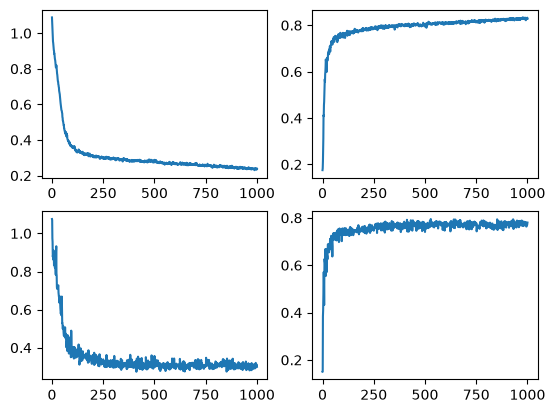

In [ ]:
# Let's plot our training and validation curves
train_logs = pd.read_csv(os.path.join(os.getcwd(),
    "Experiments/20260921-211918/train.csv"))
validation_logs = pd.read_csv(os.path.join(os.getcwd(),
    "Experiments/20260921-211918/validation.csv"))

fig, ax = plt.subplots(2, 2)
ax[0, 0].plot(train_logs['epoch'], train_logs['train_loss'])
ax[0, 1].plot(train_logs['epoch'], train_logs['train_dice'])

ax[1, 0].plot(validation_logs['epoch'], validation_logs['val_loss'])
ax[1, 1].plot(validation_logs['epoch'], validation_logs['val_dice'])

# What are your observations?

In [ ]:
# Let's start testing our model

# First we load our model
model_path = os.path.join(
    os.getcwd(),
    "Experiments/20260921-211918/saved_models/model_weights1000.pt",
)

model_c = UNet(1, 0.1).to(device=DEVICE)
if DEVICE == 'cpu':
    model_c.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
else:
    model_c.load_state_dict(torch.load(model_path, weights_only=False))
model_c.eval()

UNet(
  (max_pool_2x2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down_conv_1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): PReLU(num_parameters=1)
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): PReLU(num_parameters=1)
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (down_conv_2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): PReLU(num_parameters=1)
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): PReLU(num_parameters=1)
    (6): BatchNorm2d(64, eps=1e-05, mo

In [ ]:
# Load test data
data_path_test = Path(Path.cwd() / "dataset/test")
images_test, ground_truths_test = load_dataset(data_path=data_path, resize_dims=(512, 512), convert_to_grayscale=True)

In [ ]:
# Calculate scores for each test case
def dice_coefficient(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred))

cases = []
predictions = []
threshold = 0.5

with torch.no_grad():
    for i, image in enumerate(images_test):
        # Create 4D Tensor input
        input = np.expand_dims(image, 0)
        input = np.expand_dims(input, 0)
        input = torch.Tensor(input)
        input = input.to(DEVICE, dtype=torch.float)

        # Predict
        prediction = model_c(input)
        prediction = prediction.squeeze()
        prediction = prediction.detach().cpu().numpy()

        prediction[prediction > threshold] = 1
        prediction[prediction != 1] = 0
        predictions.append(prediction)

        target = ground_truths_test[i]
        dice = dice_coefficient(target, prediction)
        cases.append(dice)

print(f"Mean dice for test cases: {np.mean(cases)}")

Mean dice for test cases: 0.8635271113748676


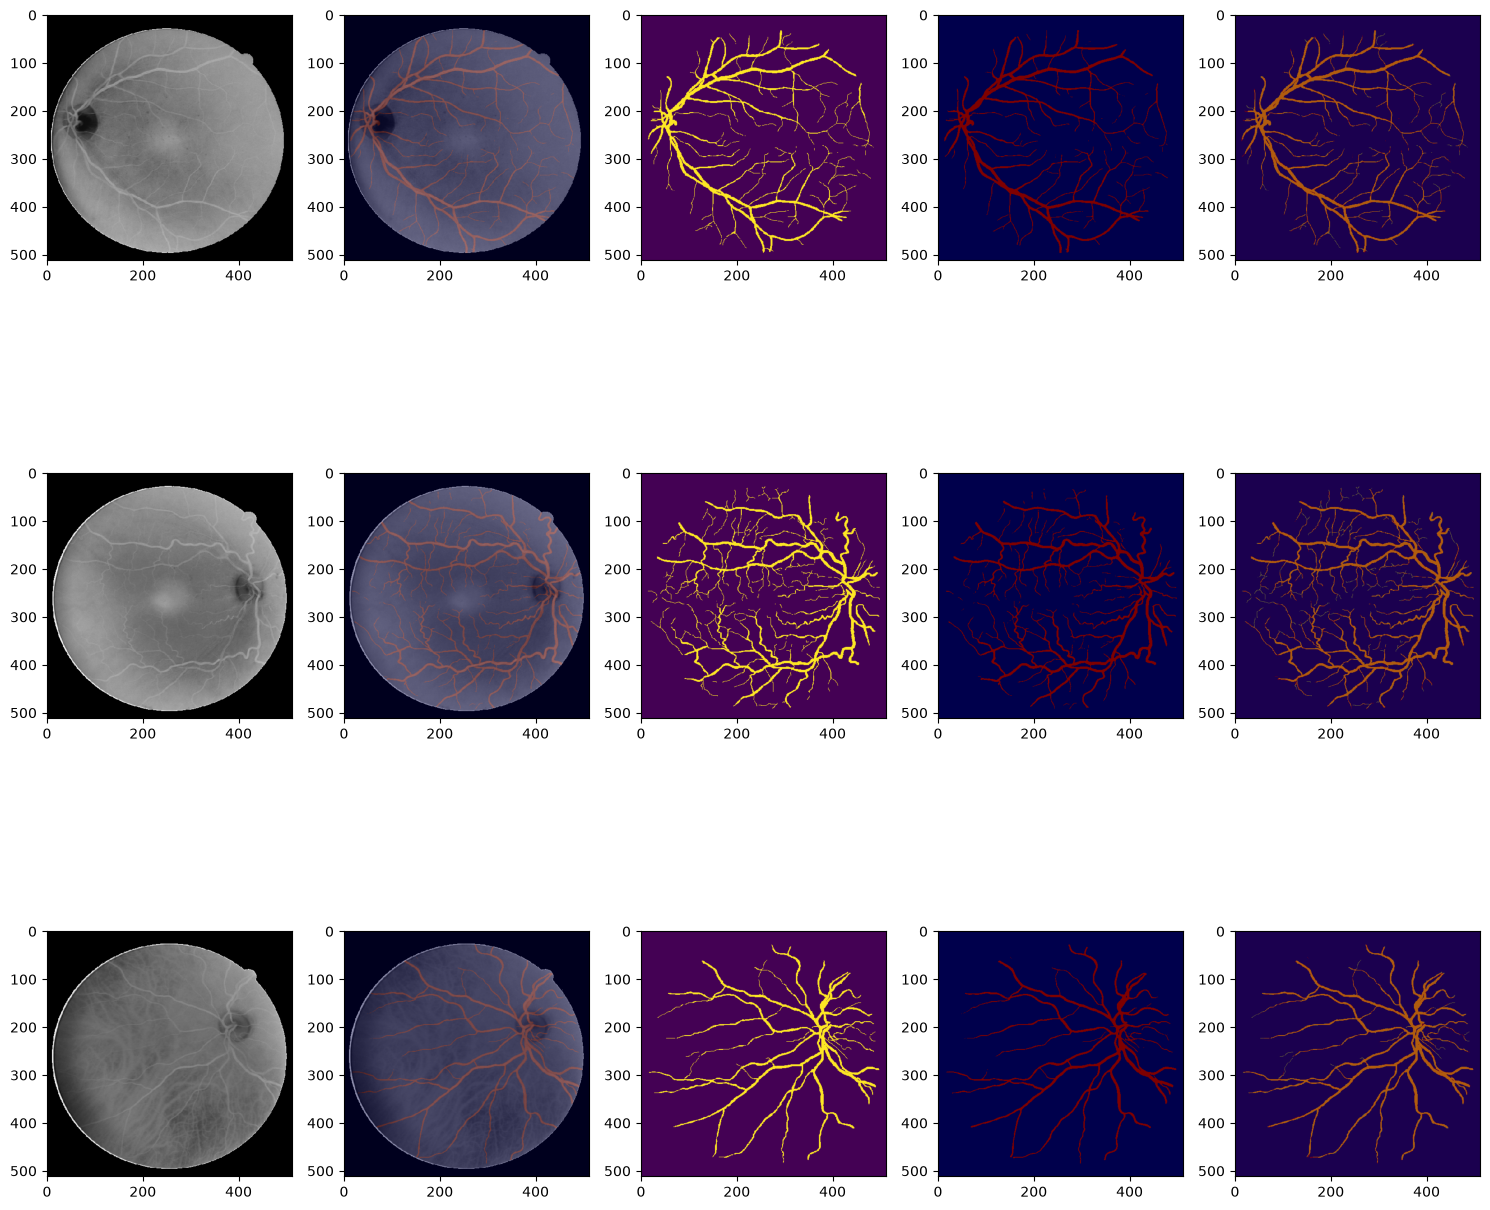

In [39]:
# Let's visualize
fig, ax = plt.subplots(3,5, figsize=(15, 15))
ax[0, 0].imshow(images_test[0], cmap= 'gray')
ax[0, 1].imshow(images_test[0], cmap= 'gray')
ax[0, 1].imshow(predictions[0], cmap='seismic', alpha=0.4)
ax[0, 2].imshow(ground_truths_test[0])
ax[0, 3].imshow(predictions[0], cmap='seismic')
ax[0, 4].imshow(predictions[0], cmap='seismic')
ax[0, 4].imshow(ground_truths_test[0], alpha=0.4)


ax[1, 0].imshow(images_test[1], cmap='gray')
ax[1, 1].imshow(images_test[1], cmap= 'gray')
ax[1, 1].imshow(predictions[1], cmap='seismic', alpha=0.4)
ax[1, 2].imshow(ground_truths_test[1])
ax[1, 3].imshow(predictions[1], cmap='seismic')
ax[1, 4].imshow(predictions[1], cmap='seismic')
ax[1, 4].imshow(ground_truths_test[1], alpha=0.4)


ax[2, 0].imshow(images_test[2], cmap='gray')
ax[2, 1].imshow(images_test[2], cmap= 'gray')
ax[2, 1].imshow(predictions[2], cmap='seismic', alpha=0.4)
ax[2, 2].imshow(ground_truths_test[2])
ax[2, 3].imshow(predictions[2], cmap='seismic')
ax[2, 4].imshow(predictions[2], cmap='seismic')
ax[2, 4].imshow(ground_truths_test[2], alpha=0.4)


plt.tight_layout()

In [ ]:
# What can we do to improve our model?
# What are the next steps if we want to validate it in another clinic?